In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Titanic-Dataset.csv')

def clean_data(df):
    df['Age'] = df['Age'].fillna(df['Age'].mean())
    if 'Cabin' in df.columns:
        df = df.drop(columns=['Cabin'])
    df = df.dropna()
    return df

df = clean_data(df)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


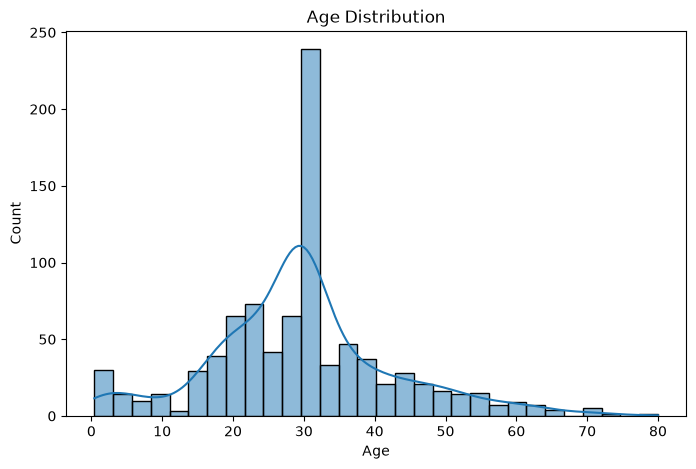

In [68]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

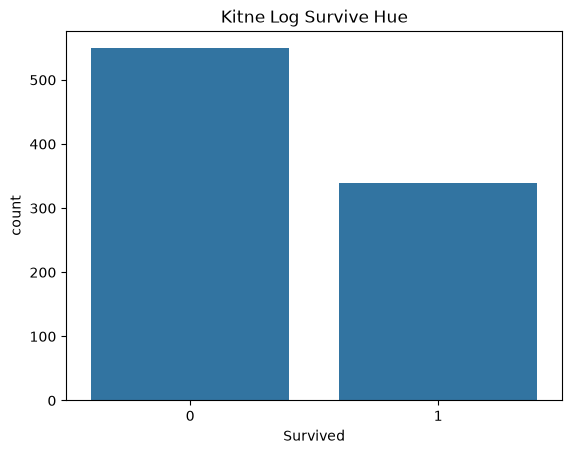

In [69]:
sns.countplot(x='Survived', data=df)
plt.title('Kitne Log Survive Hue')
plt.show()


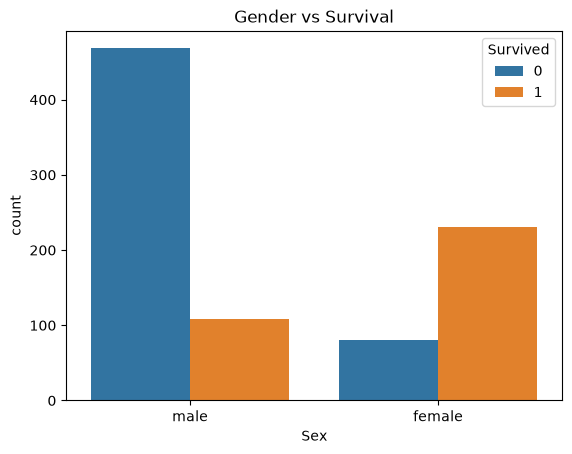

In [70]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Gender vs Survival')
plt.show()

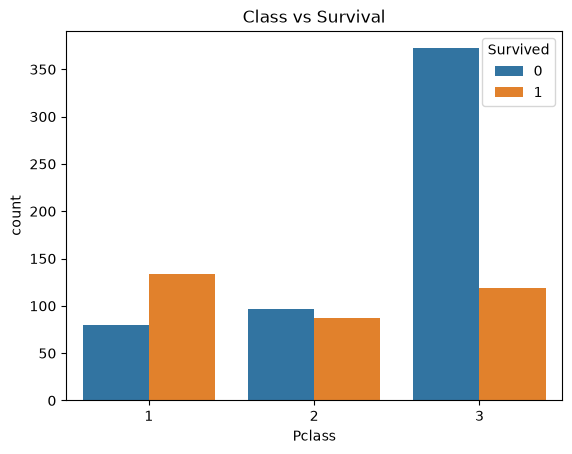

In [71]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Class vs Survival')
plt.show()

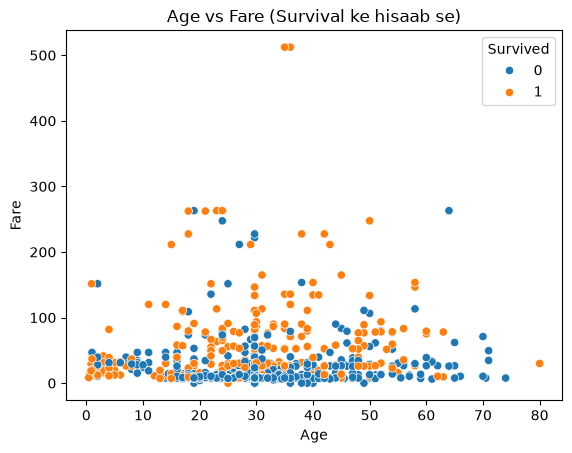

In [72]:
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.title('Age vs Fare (Survival ke hisaab se)')
plt.show()

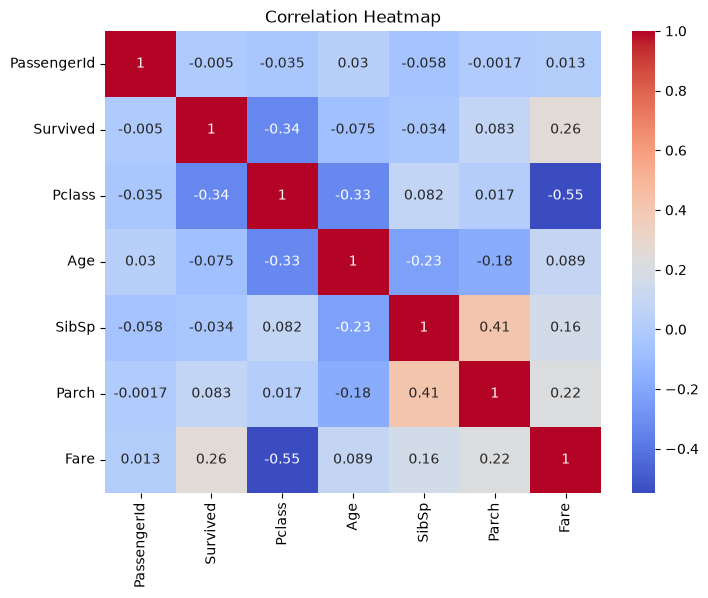

In [73]:
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [74]:
# Male/Female ko 0/1 mein convert karo
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# Embarked (S/C/Q) ko encode karo
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,1,0,A/5 21171,7.2500,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,1,0,PC 17599,71.2833,False,False
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,0,0,STON/O2. 3101282,7.9250,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,1,0,113803,53.1000,False,True
4,5,0,3,"Allen, Mr. William Henry",0,35.0,0,0,373450,8.0500,False,True


In [75]:
df = df.drop(columns=['Name', 'Ticket', 'PassengerId'])
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [76]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

numeric_features = ['Age', 'Fare']
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features)
])

pipeline = Pipeline(steps=[('preprocessor', preprocessor)])
print("Pipeline ready hai")


Pipeline ready hai


## Day 3 — EDA Observations

- Overall survival rate kam tha — zyada log survive nahi hue (~38%)
- Females ka survival rate males se bahut zyada tha (~74% vs ~19%)
- Passenger Class ka bhi bada asar tha — Class 1 mein zyada survival, Class 3 mein sabse kam
- Fare aur Class ke beech strong relation dikha — mehnge tickets wale zyada survive hue
- Age ka survival pe utna direct asar nahi dikha jitna Gender aur Class ka tha